In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import spearmanr, ConstantInputWarning
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm
import glob
import math

In [2]:
# ============================================================
# Fonts / style
# ============================================================
font_paths = [
    "/home/gzu5140/Font/Arial.ttf",
    "/home/gzu5140/Font/Arial Bold.ttf",
    "/home/gzu5140/Font/Arial Italic.ttf",
    "/home/gzu5140/Font/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

✔ Loaded font: /home/gzu5140/Font/Arial.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold Italic.ttf


In [3]:
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18*1.5      # x/y labels
plt.rcParams['axes.titlesize'] = 20*1.5 
plt.rcParams['xtick.labelsize'] = 12*1.5     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12*1.5    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12*1.5     # legend text

plt.rcParams['figure.dpi'] = 400
plt.rcParams['axes.grid'] = False

# silence scipy's constant-input warning globally (we handle it ourselves)
warnings.filterwarnings("ignore", category=ConstantInputWarning)

In [4]:
# ============================================================
# Helpers
# ============================================================
def _safe_name(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "._- " else "_" for ch in str(s))

def _spearman(a, b):
    """
    Spearman rank correlation with finite mask and constant-array guard.
    Returns NaN if <3 finite points or either vector is constant.
    """
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan

    a_ = a[mask]
    b_ = b[mask]

    # If either array is constant, Spearman is undefined
    if np.all(a_ == a_[0]) or np.all(b_ == b_[0]):
        return np.nan

    r, _ = spearmanr(a_, b_)
    return float(r)

In [5]:
import pandas as pd
import numpy as np
import os
from typing import List, Dict, Optional
from scipy.stats import spearmanr


def spearman_cross_twins_vectorized(
    df_t1: pd.DataFrame,
    df_t2: pd.DataFrame,
    gene_cols: List[str],
    type_comparison: str = "twin"
) -> pd.DataFrame:
    """
    Compute cross-time Spearman correlations between two timepoints.
    
    Uses half-sampling and computes bidirectional correlations for each gene pair.
    """
    # Merge on clone_id to align twin pairs
    merged = df_t1.merge(df_t2, on="clone_id", how="inner", suffixes=("_t1", "_t2"))
    
    if merged.empty:
        return pd.DataFrame(
            columns=["gene_pair", "Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]
        ).set_index("gene_pair")
    
    # Half-sample clones
    if len(merged) >= 2:
        n_keep = len(merged) // 2
        merged = merged.sample(n=n_keep, replace=False).reset_index(drop=True)
    
    # Randomly permute t2 data if comparison type is random
    if type_comparison == "random":
        perm = np.random.permutation(len(merged))
        for col in gene_cols:
            merged[f"{col}_t2"] = merged[f"{col}_t2"].values[perm]
    
    # Compute correlations for all gene pairs
    rows = []
    for g1, g2 in PAIR_ORDER:
        # Forward: g1(t1) → g2(t2)
        r_forward, _ = spearmanr(merged[f"{g1}_t1"], merged[f"{g2}_t2"], nan_policy='omit')
        
        # Reverse: g2(t1) → g1(t2)
        r_reverse, _ = spearmanr(merged[f"{g2}_t1"], merged[f"{g1}_t2"], nan_policy='omit')
        
        rows.append({
            "gene_pair": PAIR_LABELS[(g1, g2)],
            "Spearman(x_t1,y_t2)": r_forward,
            "Spearman(y_t1,x_t2)": r_reverse,
        })
    
    return pd.DataFrame(rows).set_index("gene_pair")


def process_single_file_all_t2(
    df: pd.DataFrame,
    t1: int,
    t2_values: List[int],
    time_col: str,
    gene_cols: List[str],
    repA: str,
    repB: str,
    type_comparison: str = "twin"
) -> Dict[int, pd.DataFrame]:
    """
    Process a single file for all t2 values efficiently.
    
    Extracts t1 data once, then computes correlations with each t2 timepoint.
    Returns dict mapping t2 -> correlation results.
    """
    # Extract t1 data once
    df_t1_raw = df[(df[time_col] == t1) & (df["replicate"] == repA)].copy()
    
    # Aggregate duplicates for t1
    if df_t1_raw["clone_id"].duplicated().any():
        df_t1 = df_t1_raw.groupby("clone_id", as_index=False)[gene_cols].mean()
    else:
        df_t1 = df_t1_raw[["clone_id"] + gene_cols]
    
    # Get all t2 data at once
    t2_mask = df[time_col].isin(t2_values) & (df["replicate"] == repB)
    df_t2_all = df[t2_mask].copy()
    
    # Aggregate duplicates within each t2 group
    if df_t2_all["clone_id"].duplicated().any():
        df_t2_all = df_t2_all.groupby([time_col, "clone_id"], as_index=False)[gene_cols].mean()
    else:
        df_t2_all = df_t2_all[[time_col, "clone_id"] + gene_cols]
    
    # Validate twin matching if needed
    if type_comparison == "twin":
        clones_t1 = set(df_t1["clone_id"])
        for t2 in t2_values:
            df_t2_current = df_t2_all[df_t2_all[time_col] == t2]
            clones_t2 = set(df_t2_current["clone_id"])
            if clones_t1 != clones_t2:
                raise ValueError(f"Clone mismatch between t1={t1} and t2={t2}")
    
    # Process each t2
    results = {}
    for t2 in t2_values:
        df_t2 = df_t2_all[df_t2_all[time_col] == t2][["clone_id"] + gene_cols]
        results[t2] = spearman_cross_twins_vectorized(df_t1, df_t2, gene_cols, type_comparison)
    
    return results


def build_tidy_for_files(
    files: List[str],
    motif_name: str,
    t1: int,
    t2_values: List[int],
    time_col: str,
    y_col: str,
    x1_col: str,
    x2_col: str,
    rep_t1: Optional[str] = None,
    rep_t2: Optional[str] = None,
    type_comparison: str = "twin"
) -> pd.DataFrame:
    """
    Build tidy DataFrame with Spearman correlations across files and timepoints.
    
    Optimized to read each file once and process all t2 values together.
    Returns long-format DataFrame with columns:
        ['motif', 'file', 't1', 't2', 'gene_pair', 'metric', 'value']
    """
    # Remove duplicates and validate files exist
    files = [f for f in dict.fromkeys(files) if f and os.path.isfile(f)]
    
    if not files:
        print(f"[warn] No valid files for motif: {motif_name}")
        return pd.DataFrame(columns=["motif", "file", "t1", "t2", "gene_pair", "metric", "value"])
    
    print(f"[info] {motif_name}: processing {len(files)} files")
    
    gene_cols = [y_col, x1_col, x2_col]
    records = []
    files_processed = 0
    files_failed = 0
    
    for fp in files:
        base = os.path.basename(fp)
        
        try:
            # Read file once
            df = pd.read_csv(fp)
            
            # Diagnostic: check if required columns exist
            required_cols = [time_col, 'replicate', 'clone_id'] + gene_cols
            missing_cols = [col for col in required_cols if col not in df.columns]
            if missing_cols:
                print(f"[warn] {motif_name} | {base}: missing columns {missing_cols}")
                files_failed += 1
                continue
            
            # Diagnostic: check if data exists for t1 and t2_values
            available_times = df[time_col].unique()
            if t1 not in available_times:
                print(f"[warn] {motif_name} | {base}: t1={t1} not in data (available: {sorted(available_times)})")
                files_failed += 1
                continue
            
            missing_t2 = [t2 for t2 in t2_values if t2 not in available_times]
            if missing_t2:
                print(f"[warn] {motif_name} | {base}: t2 values {missing_t2} not in data")
            
            # Detect twin scheme if not provided
            repA, repB = (rep_t1, rep_t2) if rep_t1 and rep_t2 else detect_twins_scheme(df)
            
            # Process all t2 values at once
            all_results = process_single_file_all_t2(
                df, t1, t2_values, time_col, gene_cols, repA, repB, type_comparison
            )
            
            # Convert results to records
            results_count = 0
            for t2, tbl in all_results.items():
                if tbl.empty:
                    continue
                for gp, row in tbl.iterrows():
                    for metric in METRICS_TO_PLOT:
                        val = row.get(metric, np.nan)
                        records.append({
                            "motif": motif_name,
                            "file": base,
                            "t1": int(t1),
                            "t2": int(t2),
                            "gene_pair": gp,
                            "metric": metric,
                            "value": None if pd.isna(val) else float(val),
                        })
                        results_count += 1
            
            if results_count > 0:
                files_processed += 1
            else:
                print(f"[warn] {motif_name} | {base}: no results generated")
                files_failed += 1
        
        except Exception as e:
            print(f"[warn] {motif_name} | {base}: {type(e).__name__}: {e}")
            import traceback
            traceback.print_exc()
            files_failed += 1
            continue
    
    print(f"[info] {motif_name}: {files_processed} files processed successfully, {files_failed} failed")
    
    if not records:
        print(f"[warn] {motif_name}: No records collected from any files")
        return pd.DataFrame(columns=["motif", "file", "t1", "t2", "gene_pair", "metric", "value"])
    
    return pd.DataFrame(records)

In [6]:
def detect_twins_scheme(df: pd.DataFrame):
    """
    Decide which replicate labels are twin A and twin B for this file.

    - If replicates include 0 and 1  -> A = 0, B = 1
    - Else if replicates include 1 and 2 (and no 0) -> A = 1, B = 2
    - Otherwise, raise an error.
    """
    reps = set(df["replicate"].dropna().unique())

    if {0, 1}.issubset(reps):
        return 0, 1   # twin A, twin B
    elif {1, 2}.issubset(reps) and 0 not in reps:
        return 1, 2   # twin A, twin B
    else:
        raise ValueError(f"Cannot infer twin scheme from replicates: {sorted(reps)}")

# # ============================================================
# # Twins: cross-time Spearman (twin A @ t1, twin B @ t2)
# # with HALF the clones used for cross-twin pairs
# # ============================================================
def spearman_cross_twins_per_file_like_matrix(
    filepath,
    t1,
    t2,
    time_col=None,
    y_col=None,
    x1_col=None,
    x2_col=None,
    rep_t1=None,
    rep_t2=None,
    type_comparison="twin",  # "twin" or "random"
) -> pd.DataFrame:
    """
    Compute cross-time Spearman correlations using *half* the clones as real twins.

    For each undirected gene pair (g1, g2) in PAIR_ORDER, we return:
      - Spearman(x_t1,y_t2): g1(t1, A) vs g2(t2, B)
      - Spearman(y_t1,x_t2): g2(t1, A) vs g1(t2, B)

    If type_comparison == "random", we break the twin pairing by
    randomly permuting the t2 rows *within* that half-sampled set.
    """
    df = pd.read_csv(filepath)

    # decide which replicate labels are twin A / twin B for THIS file
    if rep_t1 is None or rep_t2 is None:
        repA, repB = detect_twins_scheme(df)
    else:
        repA, repB = rep_t1, rep_t2

    base_cols = ["clone_id", "replicate", y_col, x1_col, x2_col]

    # ---------- slice twin A at t1, twin B at t2 ----------
    df_t1 = df.loc[
        (df[time_col] == t1) & (df["replicate"] == repA),
        base_cols
    ].copy()
    df_t2 = df.loc[
        (df[time_col] == t2) & (df["replicate"] == repB),
        base_cols
    ].copy()

    # average if multiple rows per clone
    if df_t1.duplicated(subset=["clone_id"]).any():
        df_t1 = df_t1.groupby("clone_id", as_index=False).mean(numeric_only=True)
    if df_t2.duplicated(subset=["clone_id"]).any():
        df_t2 = df_t2.groupby("clone_id", as_index=False).mean(numeric_only=True)

    # ---------- strict twin safety check on clone_id sets ----------
    clones_t1 = set(df_t1["clone_id"])
    clones_t2 = set(df_t2["clone_id"])

    if type_comparison == "twin":
        if clones_t1 != clones_t2:
            only_t1 = sorted(clones_t1 - clones_t2)
            only_t2 = sorted(clones_t2 - clones_t1)
            print("[error] Twin mismatch between t1 and t2 for file:", filepath)
            print(f"  t1 (rep={repA}) clones: {len(clones_t1)}")
            print(f"  t2 (rep={repB}) clones: {len(clones_t2)}")
            if only_t1:
                print("  present only at t1 (first few):", only_t1[:10])
            if only_t2:
                print("  present only at t2 (first few):", only_t2[:10])
            raise ValueError("Mismatch in clone_id sets between t1 and t2 for twin comparison")

    # tag t1 / t2 so we have both copies in the merge
    rename_t1 = {col: f"{col}_t1" for col in [y_col, x1_col, x2_col]}
    rename_t2 = {col: f"{col}_t2" for col in [y_col, x1_col, x2_col]}

    df_t1 = df_t1.rename(columns=rename_t1)
    df_t2 = df_t2.rename(columns=rename_t2)

    # ---------- align twins by clone_id ----------
    merged = df_t1.merge(df_t2, on="clone_id", how="inner")

    if merged.empty:
        cols = ["gene_pair", "Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]
        return pd.DataFrame(columns=cols).set_index("gene_pair")

    # ---------- HALF-sampling of clones for cross-twin pairs ----------
    n_total = len(merged)
    if n_total >= 2:
        n_keep = n_total // 2  # floor, half the clones
        idx = np.random.permutation(n_total)[:n_keep]
        merged = merged.iloc[idx].reset_index(drop=True)

    # ---------- random comparison: break twin pairing ----------
    if type_comparison == "random":
        n = len(merged)
        perm = np.random.permutation(n)
        merged_rand = merged.copy()
        for col in [f"{y_col}_t2", f"{x1_col}_t2", f"{x2_col}_t2"]:
            merged_rand[col] = merged[col].values[perm]
        used_df = merged_rand
    else:
        used_df = merged

    # ---------- compute directional Spearman ----------
    rows = []
    for (g1, g2) in PAIR_ORDER:
        # forward: g1(t1, A) → g2(t2, B)
        x_forward = used_df[f"{g1}_t1"].values
        y_forward = used_df[f"{g2}_t2"].values
        r_forward = _spearman(x_forward, y_forward)

        # reverse: g2(t1, A) → g1(t2, B)
        x_reverse = used_df[f"{g2}_t1"].values
        y_reverse = used_df[f"{g1}_t2"].values
        r_reverse = _spearman(x_reverse, y_reverse)

        rows.append({
            "gene_pair": PAIR_LABELS[(g1, g2)],  # "X-Y", "Z-Y", "Z-X"
            "Spearman(x_t1,y_t2)": r_forward,
            "Spearman(y_t1,x_t2)": r_reverse,
        })

    return pd.DataFrame(rows).set_index("gene_pair")

# # ============================================================
# # Twins: build tidy table over t2 for all files in a motif
# # ============================================================
def build_tidy_for_files(files, motif_name, t1, t2_values, time_col=None, y_col=None, x1_col=None, x2_col=None, rep_t1=None, rep_t2=None, type_comparison="twin"):
    """
    Twins:
    Returns tidy DataFrame:
      ['motif','file','t1','t2','gene_pair','metric','value']
    for metrics in METRICS_TO_PLOT.
    """
    files = [p for p in dict.fromkeys(files) if p and os.path.isfile(p)]
    if not files:
        print(f"[warn] No valid files for motif: {motif_name}")
        return pd.DataFrame(columns=["motif","file","t1","t2","gene_pair","metric","value"])

    print(f"[info] {motif_name}: using {len(files)} twin files")
    records = []

    for fp in files:
        base = os.path.basename(fp)
        for t2 in t2_values:
            try:
                tbl = spearman_cross_twins_per_file_like_matrix(
                    fp, t1, t2,
                    time_col=time_col,
                    y_col=y_col,
                    x1_col=x1_col,
                    x2_col=x2_col,
                    type_comparison="twin",
                )
            except Exception as e:
                print(f"[warn] {motif_name} | {base} | t2={t2}: {e}")
                continue

            for gp, row in tbl.iterrows():
                for metric in METRICS_TO_PLOT:
                    val = row.get(metric, np.nan)
                    records.append({
                        "motif":     motif_name,
                        "file":      base,
                        "t1":        int(t1),
                        "t2":        int(t2),
                        "gene_pair": gp,
                        "metric":    metric,
                        "value":     None if pd.isna(val) else float(val),
                    })

    return pd.DataFrame.from_records(records)

# ============================================================
# Regular: population gene-gene Spearman (full population, per time)
# ============================================================
def build_tidy_regular_for_files(files, motif_name, t_values=None, t1=None):
    """
    Population gene-gene Spearman *per time point*, using the full population.

    Returns tidy DataFrame:
      ['motif','file','t1','t2','gene_pair','metric','value']
    where 't2' is the time t on the x-axis and
    'metric' == "Spearman_same_time".
    """
    files = [p for p in dict.fromkeys(files) if p and os.path.isfile(p)]
    if not files:
        print(f"[warn] No valid files for motif (regular): {motif_name}")
        return pd.DataFrame(columns=["motif","file","t1","t2","gene_pair","metric","value"])

    print(f"[info-pop] {motif_name}: computing population corr at each time")
    records = []

    for fp in files:
        base = os.path.basename(fp)
        try:
            df = pd.read_csv(fp)
        except Exception as e:
            print(f"[warn-pop] {motif_name} | {base}: {e}")
            continue

        # Decide which replicate is twin B (population uses B only)
        try:
            repA, repB = detect_twins_scheme(df)
        except ValueError as e:
            print(f"[warn-pop] {motif_name} | {base}: {e}")
            continue

        # Determine which times to evaluate
        if t_values is None:
            times = np.sort(df[time_col].dropna().unique())
        else:
            times = np.array(sorted(set(int(t) for t in t_values)))

        for t in times:
            # Full population at time t: all B-cells at that time
            sub = df[
                (df["replicate"] == repB) &
                (df[time_col] == t)
            ].dropna(subset=[x1_col, x2_col, y_col])

            if sub.empty:
                continue

            # Population correlations at this time t, using ALL cells in sub
            rho_xy = _spearman(sub[x1_col], sub[x2_col])  # X-Y
            rho_zy = _spearman(sub[y_col],  sub[x2_col])  # Z-Y
            rho_zx = _spearman(sub[y_col],  sub[x1_col])  # Z-X

            for (g1, g2) in PAIR_ORDER:
                gp = PAIR_LABELS[(g1, g2)]   # "X-Y", "Z-Y", "Z-X"
                if gp == "X-Y":
                    rho = rho_xy
                elif gp == "Z-Y":
                    rho = rho_zy
                elif gp == "Z-X":
                    rho = rho_zx
                else:
                    continue

                records.append({
                    "motif":     motif_name,
                    "file":      base,
                    "t1":        int(t),
                    "t2":        int(t),   # x-axis
                    "gene_pair": gp,
                    "metric":    "Spearman_same_time",
                    "value":     float(rho),
                })

    return pd.DataFrame.from_records(records)

# ============================================================
# Aggregate
# ============================================================
def aggregate_mean_std(tidy: pd.DataFrame) -> pd.DataFrame:
    """
    Group by motif, metric, gene_pair, t2 and compute mean/std/n.
    """
    if tidy.empty:
        return pd.DataFrame(columns=["motif","metric","gene_pair","t2","mean","std","n"])

    agg = (
        tidy
        .groupby(["motif", "metric", "gene_pair", "t2"], as_index=False)
        .agg(
            mean=('value', 'mean'),
            std =('value', 'std'),
            n   =('value', 'count'),
        )
    )
    return agg

# ============================================================
# Plotter: ONE panel per motif, overlay rho_hat twins + rho_pop
# ============================================================
def plot_three_motifs_panels(agg_twin: pd.DataFrame,
                             agg_reg: pd.DataFrame,
                             motifs_order=None,
                             outpath=None):
    """
    Make a 1x3 panel figure (Fan-out, Feed-forward Loop, Regulated Mutual).

    Colored twins:
      Z→X  solid blue   (#3E8ED0)  (pair Z-X, forward metric)
      Z→Y  solid yellow (#F5B700)  (pair Z-Y, forward metric)
      X→Y  solid red    (#D73027)  (pair X-Y, forward metric)
      Y→X  solid green  (#00A676)  (pair X-Y, reverse metric)

    PLUS (for X–Y only):
      - black dashed line  = population ρ_s(t,t) (steady-state, flat)
      - gray band          = ± std of population ρ_s(t,t) across files
    """
    if motifs_order is None:
        motifs_order = list(MOTIF_FILES.keys())

    fig, axes = plt.subplots(1, 3, sharey=True, figsize=(22, 6.5))

    for ax, motif in zip(axes, motifs_order):
        ax.axhline(y=0, color="gray", linestyle="--", linewidth=1.5, alpha=0.6)
        sub_twin = agg_twin[agg_twin["motif"] == motif]
        sub_reg  = agg_reg[agg_reg["motif"] == motif]

        if sub_twin.empty:
            print(f"[plot] No twin rows for motif={motif}")
            continue

        # ---------- Z→X (pair Z-X, forward metric) ----------
        label_zx = "Z-X"
        zx = sub_twin[
            (sub_twin["gene_pair"] == label_zx) &
            (sub_twin["metric"] == "Spearman(x_t1,y_t2)")
        ].sort_values("t2")
        if not zx.empty:
            t = zx["t2"].values
            m = zx["mean"].values
            sd = zx["std"].values
            ax.plot(t, m, lw=2.5, color=COL_ZX, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd,
                                color=COL_ZX, alpha=0.15, linewidth=0)

        # ---------- Z→Y (pair Z-Y, forward metric) ----------
        label_zy = "Z-Y"
        zy = sub_twin[
            (sub_twin["gene_pair"] == label_zy) &
            (sub_twin["metric"] == "Spearman(x_t1,y_t2)")
        ].sort_values("t2")
        if not zy.empty:
            t = zy["t2"].values
            m = zy["mean"].values
            sd = zy["std"].values
            ax.plot(t, m, lw=2.5, color=COL_ZY, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd,
                                color=COL_ZY, alpha=0.15, linewidth=0)

        # ---------- X→Y (pair X-Y, forward metric, twins) ----------
        label_xy = "X-Y"
        xy = sub_twin[
            (sub_twin["gene_pair"] == label_xy) &
            (sub_twin["metric"] == "Spearman(x_t1,y_t2)")
        ].sort_values("t2")
        if not xy.empty:
            t = xy["t2"].values
            m = xy["mean"].values
            sd = xy["std"].values
            ax.plot(t, m, lw=2.5, color=COL_XY, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd,
                                color=COL_XY, alpha=0.15, linewidth=0)

        # ---------- Y→X (same X-Y pair, reverse metric, twins) ----------
        yx = sub_twin[
            (sub_twin["gene_pair"] == label_xy) &
            (sub_twin["metric"] == "Spearman(y_t1,x_t2)")
        ].sort_values("t2")
        if not yx.empty:
            t = yx["t2"].values
            m = yx["mean"].values
            sd = yx["std"].values
            ax.plot(t, m, lw=2.5, color=COL_YX, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd,
                                color=COL_YX, alpha=0.15, linewidth=0)

        # ---------- X–Y population ρ_s(t,t) (black dashed + gray band) ----------
        if not sub_reg.empty:
            reg_xy = sub_reg[
                (sub_reg["gene_pair"] == label_xy) &
                (sub_reg["metric"] == "Spearman_same_time")
            ].sort_values("t2")
            if not reg_xy.empty:
                t = reg_xy["t2"].values
                m = reg_xy["mean"].values
                sd = reg_xy["std"].values
                ax.plot(t, m, lw=2.0, color="black", ls="--")
                if np.all(np.isfinite(sd)):
                    ax.fill_between(t, m - sd, m + sd,
                                    color="0.7", alpha=0.3, linewidth=0)

        # ---------- decorations ----------
        ax.set_title(motif)
        ax.set_xlabel(r"$\mathrm{time}\ t\ [\mathrm{hours}]$")
        #ax.set_ylim(0.0, 0.2)
        ax.tick_params(labelsize=16, width=1.4)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.4)
            spine.set_edgecolor("black")

    axes[0].set_ylabel(r"Spearman Correlation")

    # ---------- legend in RIGHT subplot ----------
    legend_elements = [
        Line2D([], [], color=COL_ZX, lw=2.5, ls='-',
               label=r"Z→X $\hat{\rho}^{\dagger}_{\,x(t_{1}) \;\rightarrow\; y(t_{2})}$"),
        Line2D([], [], color=COL_ZY, lw=2.5, ls='-',
               label=r"Z→Y $\hat{\rho}^{\dagger}_{\,x(t_{1}) \;\rightarrow\; y(t_{2})}$"),
        Line2D([], [], color=COL_XY, lw=2.5, ls='-',
               label=r"X→Y $\hat{\rho}^{\dagger}_{\,x(t_{1}) \;\rightarrow\; y(t_{2})}$"),
        Line2D([], [], color=COL_YX, lw=2.5, ls='-',
               label=r"Y→X $\hat{\rho}^{\dagger}_{\,x(t_{1}) \;\rightarrow\; y(t_{2})}$"),
        Line2D([], [], color="black", lw=2.0, ls='--',
               label=r"X→Y $\rho_{xy}$"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
    for ax in axes:
        ax.set_clip_on(False)

        if ax.title: ax.title.set_clip_on(False)
        if ax.xaxis.label: ax.xaxis.label.set_clip_on(False)
        if ax.yaxis.label: ax.yaxis.label.set_clip_on(False)

        # ticks
        for tick in ax.xaxis.get_major_ticks() + ax.xaxis.get_minor_ticks():
            tick.label1.set_clip_on(False)
            tick.label2.set_clip_on(False)
            if tick.tick1line: tick.tick1line.set_clip_on(False)
            if tick.tick2line: tick.tick2line.set_clip_on(False)

        for tick in ax.yaxis.get_major_ticks() + ax.yaxis.get_minor_ticks():
            tick.label1.set_clip_on(False)
            tick.label2.set_clip_on(False)
            if tick.tick1line: tick.tick1line.set_clip_on(False)
            if tick.tick2line: tick.tick2line.set_clip_on(False)

        # every artist in the axis
        for artist in ax.get_children():
            try:
                artist.set_clip_on(False)
            except Exception:
                pass

    fig.tight_layout()

    if outpath is not None:
        fig.savefig(
            outpath,
            format="pdf",
            bbox_inches="tight",
            facecolor="none",
            edgecolor="none",
            transparent=True,
        )
        print(f"[saved] {outpath}")

    return fig

In [8]:
# ============================================================
# Config
# ============================================================
# Gene columns (Z, X, Y)
y_col  = 'gene_1_mRNA'  # Z
x1_col = 'gene_2_mRNA'  # X
x2_col = 'gene_3_mRNA'  # Y

GENE_LABELS = {
    y_col:  "Z",   # gene_1_mRNA
    x1_col: "X",   # gene_2_mRNA
    x2_col: "Y",   # gene_3_mRNA
}

# Pair order (undirected pairs) and labels:
#   X-Y, Z-Y, Z-X
PAIR_ORDER  = [
    (x1_col, x2_col),   # X-Y
    (y_col,  x2_col),   # Z-Y
    (y_col,  x1_col),   # Z-X
]
PAIR_LABELS = {(a, b): f"{GENE_LABELS[a]}-{GENE_LABELS[b]}" for (a, b) in PAIR_ORDER}

# Colors
COL_ZX = "#3E8ED0"
COL_ZY = "#F5B700"
COL_XY = "#D73027"
COL_YX = "#00A676"

t1_fixed = 1
t2_values = list(range(1, 49))   # 1..48
time_col = 'time_step'

# Default twin definition (can be overridden; auto-detect per file anyway)
rep_t1 = 1   # twin A (at t1)
rep_t2 = 2   # twin B (at t2)

# Gene columns (Z, X, Y)
y_col  = 'gene_1_mRNA'  # Z
x1_col = 'gene_2_mRNA'  # X
x2_col = 'gene_3_mRNA'  # Y

# Metrics to compute / plot
metric_to_plot = ["Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]

additive_folder = "/home/gzu5140/Keerthana_b1042/GRNanalysis/simulation_data/mutual_reg_gene_sim/"
logic_gate_folder = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim/"
motif_patterns = {
    "additive":{
        "Fan out": {
                "folder": additive_folder,
                "pattern": "Fan_out_New_Median"
            },
        "Feed forward loop (additive)": {
            "folder": additive_folder,
            "pattern": "Feed_forward_New_Median"
        },
        "Mutual Regulation (additive)": {
            "folder": additive_folder,
            "pattern": "Mutual_regulation_New_Median"
        },
    },

    "and":{
        "Fan out": {
                "folder": additive_folder,
                "pattern": "Fan_out_New_Median"
            },
        "Feed forward loop (and)": {
            "folder": logic_gate_folder,
            "pattern": "Feed_forward_and"
        },
        "Mutual Regulation (and)": {
            "folder": logic_gate_folder,
            "pattern": "Mutual_regulation_and"
        },
    },

    "or":{
        "Fan out": {
                "folder": additive_folder,
                "pattern": "Fan_out_New_Median"
            },
        "Feed forward loop (or)": {
            "folder": logic_gate_folder,
            "pattern": "Feed_forward_or"
        },
        "Mutual Regulation (or)": {
            "folder": logic_gate_folder,
            "pattern": "Mutual_regulation_or"
        },
    }
    
}
path_to_output = "/home/gzu5140/Keerthana_b1042/grnInference/analysisData/figure_4/"
path_to_figure = "/home/gzu5140/Keerthana_b1042/grnInference/plots/warmflesh_simulations/"

In [9]:
interaction_type_dict

NameError: name 'interaction_type_dict' is not defined

In [11]:
# ============================================================
# Main
# ============================================================
RNG_SEED = 12345  # or whatever you want
rng = np.random.default_rng(RNG_SEED)
for interaction_type, interaction_type_dict in motif_patterns.items():
    print("\n########################################")
    print(f"Processing interaction TYPE: {interaction_type}")
    print("########################################")
    # One z-score dict PER interaction type (group of 3 motifs)
    all_tidy_twin = []
    all_tidy_reg = []
    # Now loop over the motifs inside this interaction type
    for motif_name, info in interaction_type_dict.items():
        folder  = info["folder"]
        pattern = info["pattern"]
        # find all matching csv files
        all_files = glob.glob(os.path.join(folder, "df*.csv"))
        file_list = [f for f in all_files if pattern in os.path.basename(f)]
        print(file_list[:2])
        if len(file_list) > 20:
            file_list = file_list[:20]
        
        # ---------- twins (t1 fixed, t2 sweep) ----------
        
        tidy_motif = build_tidy_for_files(file_list, motif_name, t1_fixed, t2_values,
                                            time_col = time_col, y_col = y_col, x1_col=x1_col,
                                            x2_col=x2_col, rep_t1=rep_t1, rep_t2=rep_t2)
        print(tidy_motif)
        if not tidy_motif.empty:
                all_tidy_twin.append(tidy_motif)
        tidy_reg_motif = build_tidy_regular_for_files(
                file_list, motif_name,
                t_values=t2_values,
                t1=t1_fixed
        )
        all_tidy_reg.append(tidy_reg_motif)
    if not all_tidy_twin:
                raise SystemExit("[abort] No twin data collected. Check paths in MOTIF_FILES.")

    tidy_twin = pd.concat(all_tidy_twin, ignore_index=True)
    tidy_reg = pd.concat(all_tidy_reg, ignore_index=True)
    agg_reg  = aggregate_mean_std(tidy_reg)
    agg_twin  = aggregate_mean_std(tidy_twin)
    path_file = f"{path_to_output}/{interaction_type}"
    os.makedirs(path_file, exist_ok = True)
    tidy_twin.to_csv(f"{path_file}/twin_data.csv")
    tidy_reg.to_csv(f"{path_file}/reg_data.csv")
    path_to_plot = f"{path_to_figure}/{interaction_type}.pdf"
    plot_three_motifs_panels(agg_twin, agg_reg, outpath = path_to_figure)
        


########################################
Processing interaction TYPE: additive
########################################
['/home/gzu5140/Keerthana_b1042/GRNanalysis/simulation_data/mutual_reg_gene_sim/df_rows_0_0_0_03122025_231037_ncells_6000_Fan_out_New_Median_2_3_621cea7d.csv', '/home/gzu5140/Keerthana_b1042/GRNanalysis/simulation_data/mutual_reg_gene_sim/df_rows_0_0_0_03122025_230406_ncells_6000_Fan_out_New_Median_2_7_41aa7a85.csv']
[info] Fan out: using 20 twin files


NameError: name 'METRICS_TO_PLOT' is not defined

In [ ]:
%tb

SystemExit: [abort] No twin data collected. Check paths in MOTIF_FILES.

In [12]:
#!/usr/bin/env python3
"""
Boxplots of z-scores for all files and motifs.

For each file:
  - t1 = 1, t2 = 20
  - Use twin A at t1, twin B at t2 (auto-detect 0/1 vs 1/2)
  - Compute global cross correlations:
        rho_XY_cross = Spearman(X_t1, Y_t2)
        rho_YX_cross = Spearman(Y_t1, X_t2)
  - Build null distribution from subsampled Z1 -> Y2 cross:
        For k in 1..N_SAMPLES:
            pick GROUP_SIZE clones (without replacement)
            rho_null[k] = Spearman(Z1[idx], Y2[idx])
  - z-scores per file:
        z_XY = (rho_XY_cross - mean(rho_null)) / std(rho_null)
        z_YX = (rho_YX_cross - mean(rho_null)) / std(rho_null)

Across all files in each motif we collect z_XY, z_YX
and make boxplots:
  - left panel: z_XY by motif
  - right panel: z_YX by motif
"""

'\nBoxplots of z-scores for all files and motifs.\n\nFor each file:\n  - t1 = 1, t2 = 20\n  - Use twin A at t1, twin B at t2 (auto-detect 0/1 vs 1/2)\n  - Compute global cross correlations:\n        rho_XY_cross = Spearman(X_t1, Y_t2)\n        rho_YX_cross = Spearman(Y_t1, X_t2)\n  - Build null distribution from subsampled Z1 -> Y2 cross:\n        For k in 1..N_SAMPLES:\n            pick GROUP_SIZE clones (without replacement)\n            rho_null[k] = Spearman(Z1[idx], Y2[idx])\n  - z-scores per file:\n        z_XY = (rho_XY_cross - mean(rho_null)) / std(rho_null)\n        z_YX = (rho_YX_cross - mean(rho_null)) / std(rho_null)\n\nAcross all files in each motif we collect z_XY, z_YX\nand make boxplots:\n  - left panel: z_XY by motif\n  - right panel: z_YX by motif\n'

In [13]:
# ============================================================
# Helpers
# ============================================================
def _spearman(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    r, _ = spearmanr(a[m], b[m])
    return float(r)

def detect_twins(df: pd.DataFrame):
    reps = set(df["replicate"].dropna().unique())
    if {0, 1}.issubset(reps):
        return 0, 1
    elif {1, 2}.issubset(reps) and 0 not in reps:
        return 1, 2
    else:
        raise ValueError(f"Cannot detect twin labels from reps={sorted(reps)}")

def load_twins(path):
    df = pd.read_csv(path)
    repA, repB = detect_twins(df)

    cols = ["clone_id", y_col, x1_col, x2_col]
    d1 = df[(df[time_col] == t1) & (df["replicate"] == repA)][cols].copy()
    d2 = df[(df[time_col] == t2) & (df["replicate"] == repB)][cols].copy()

    if d1.duplicated("clone_id").any():
        d1 = d1.groupby("clone_id", as_index=False).mean(numeric_only=True)
    if d2.duplicated("clone_id").any():
        d2 = d2.groupby("clone_id", as_index=False).mean(numeric_only=True)

    m = d1.merge(d2, on="clone_id", suffixes=("_t1", "_t2"))
    if m.empty:
        raise ValueError(f"No overlapping clones with t1 and t2 in {path}")

    Z1 = m[f"{y_col}_t1"].values
    X1 = m[f"{x1_col}_t1"].values
    Y1 = m[f"{x2_col}_t1"].values
    X2 = m[f"{x1_col}_t2"].values
    Y2 = m[f"{x2_col}_t2"].values
    return Z1, X1, Y1, X2, Y2

def compute_z_for_file(path, rng):
    """
    For a single CSV:
      - load twins
      - compute global rho_XY_cross, rho_YX_cross
      - build null(Z1->Y2) distribution via subsampling
      - return (z_XY, z_YX)
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(path)

    print(f"  [file] {os.path.basename(path)}")

    # === 关键：这里 try/except，把没有 twin 的文件直接 skip ===
    try:
        Z1, X1, Y1, X2, Y2 = load_twins(path)
    except ValueError as e:
        print(f"    [skip] twin detection failed: {e}")
        return np.nan, np.nan

    N = len(X1)
    if GROUP_SIZE > N:
        print(f"    [skip] GROUP_SIZE={GROUP_SIZE} > N={N}")
        return np.nan, np.nan

    # cross correlations using ALL clones
    rho_XY_cross = _spearman(X1, Y2)
    rho_YX_cross = _spearman(Y1, X2)

    # null: Z1 -> Y2 subsampled
    rho_null = np.empty(N_SAMPLES, dtype=float)
    for k in range(N_SAMPLES):
        idx = rng.choice(N, size=GROUP_SIZE, replace=True)
        rho_null[k] = _spearman(Z1[idx], Y2[idx])

    mu = float(np.nanmean(rho_null))
    sd = float(np.nanstd(rho_null, ddof=1))
    if sd <= 0 or not np.isfinite(sd):
        print("    [skip] null sd <= 0 or not finite")
        return np.nan, np.nan

    z_XY = (rho_XY_cross - mu) / sd
    z_YX = (rho_YX_cross - mu) / sd

    print(
        f"    rho_XY_cross={rho_XY_cross:.3f}, rho_YX_cross={rho_YX_cross:.3f}, "
        f"mu_null={mu:.3f}, sd_null={sd:.3f}, "
        f"z_XY={z_XY:.3f}, z_YX={z_YX:.3f}"
    )

    return z_XY, z_YX


# ============================================================
# Plotting
# ============================================================
def plot_boxplots(z_by_motif_XY, z_by_motif_YX):
    motifs = list(z_by_motif_XY.keys())
    # ensure same order in both dicts
    assert motifs == list(z_by_motif_YX.keys())

    x_positions = np.arange(1, len(motifs) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
    fig.suptitle(
        r"z-scores of cross vs null "
        r"$\rho^{\dagger}_{z(t_1)\to y(t_2)}$ (group size = %d)" % GROUP_SIZE
    )

    # Left panel: z_XY
    ax = axes[0]
    box_data_XY = [np.array(z_by_motif_XY[m]) for m in motifs]
    b1 = ax.boxplot(
        box_data_XY,
        positions=x_positions,
        widths=0.6,
        patch_artist=True,
        showfliers=True,
    )
    for patch, m in zip(b1['boxes'], motifs):
        patch.set_facecolor(MOTIF_COLORS.get(m, "0.8"))
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(motifs, rotation=20, ha="right")
    ax.set_ylabel("z-score")
    ax.set_title("X→Y cross (z_XY)")

    # Right panel: z_YX
    ax = axes[1]
    box_data_YX = [np.array(z_by_motif_YX[m]) for m in motifs]
    b2 = ax.boxplot(
        box_data_YX,
        positions=x_positions,
        widths=0.6,
        patch_artist=True,
        showfliers=True,
    )
    for patch, m in zip(b2['boxes'], motifs):
        patch.set_facecolor(MOTIF_COLORS.get(m, "0.8"))
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(motifs, rotation=20, ha="right")
    ax.set_title("Y→X cross (z_YX)")

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
            spine.set_edgecolor("black")

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

In [14]:
import os
import glob

# Config
# ============================================================
t1 = 1
t2 = 20

time_col = "time_step"
y_col  = "gene_1_mRNA"   # Z
x1_col = "gene_2_mRNA"   # X
x2_col = "gene_3_mRNA"   # Y

RNG_SEED   = 20251128
N_SAMPLES  = 10000
GROUP_SIZE = 1500   # same as your last script

DATA_DIR = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/warmflesh_mutual_reg/"

additive_folder = "/home/gzu5140/Keerthana_b1042/GRNanalysis/simulation_data/mutual_reg_gene_sim/"
logic_gate_folder = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim/"
motif_patterns = {
    "additive":{
        "Fan out": {
                "folder": additive_folder,
                "pattern": "Fan_out_New_Median"
            },
        "Feed forward loop (additive)": {
            "folder": additive_folder,
            "pattern": "Feed_forward_New_Median"
        },
        "Mutual Regulation (additive)": {
            "folder": additive_folder,
            "pattern": "Mutual_regulation_New_Median"
        },
    },

    "and":{
        "Fan out": {
                "folder": additive_folder,
                "pattern": "Fan_out_New_Median"
            },
        "Feed forward loop (and)": {
            "folder": logic_gate_folder,
            "pattern": "Feed_forward_and"
        },
        "Mutual Regulation (and)": {
            "folder": logic_gate_folder,
            "pattern": "Mutual_regulation_and"
        },
    },

    "or":{
        "Fan out": {
                "folder": additive_folder,
                "pattern": "Fan_out_New_Median"
            },
        "Feed forward loop (or)": {
            "folder": logic_gate_folder,
            "pattern": "Feed_forward_or"
        },
        "Mutual Regulation (or)": {
            "folder": logic_gate_folder,
            "pattern": "Mutual_regulation_or"
        },
    }
    
}



########################################
Processing interaction TYPE: additive
########################################

------------------------------
Motif: Fan out
------------------------------
Found 20 files
  [file] df_rows_0_0_0_03122025_231037_ncells_6000_Fan_out_New_Median_2_3_621cea7d.csv
    rho_XY_cross=0.107, rho_YX_cross=0.089, mu_null=0.126, sd_null=0.026, z_XY=-0.724, z_YX=-1.442
  [file] df_rows_0_0_0_03122025_230406_ncells_6000_Fan_out_New_Median_2_7_41aa7a85.csv
    rho_XY_cross=0.107, rho_YX_cross=0.077, mu_null=0.121, sd_null=0.025, z_XY=-0.549, z_YX=-1.737
  [file] df_rows_0_0_0_03122025_222342_ncells_6000_Fan_out_New_Median_k_on0_3_1_6a23b0f0.csv
    rho_XY_cross=0.086, rho_YX_cross=0.083, mu_null=0.115, sd_null=0.025, z_XY=-1.140, z_YX=-1.257
  [file] df_rows_0_0_0_04122025_001948_ncells_6000_Fan_out_New_Median_k_on0_3_6_e20e08a1.csv
    rho_XY_cross=0.100, rho_YX_cross=0.114, mu_null=0.108, sd_null=0.025, z_XY=-0.330, z_YX=0.216
  [file] df_rows_0_0_0_03122025

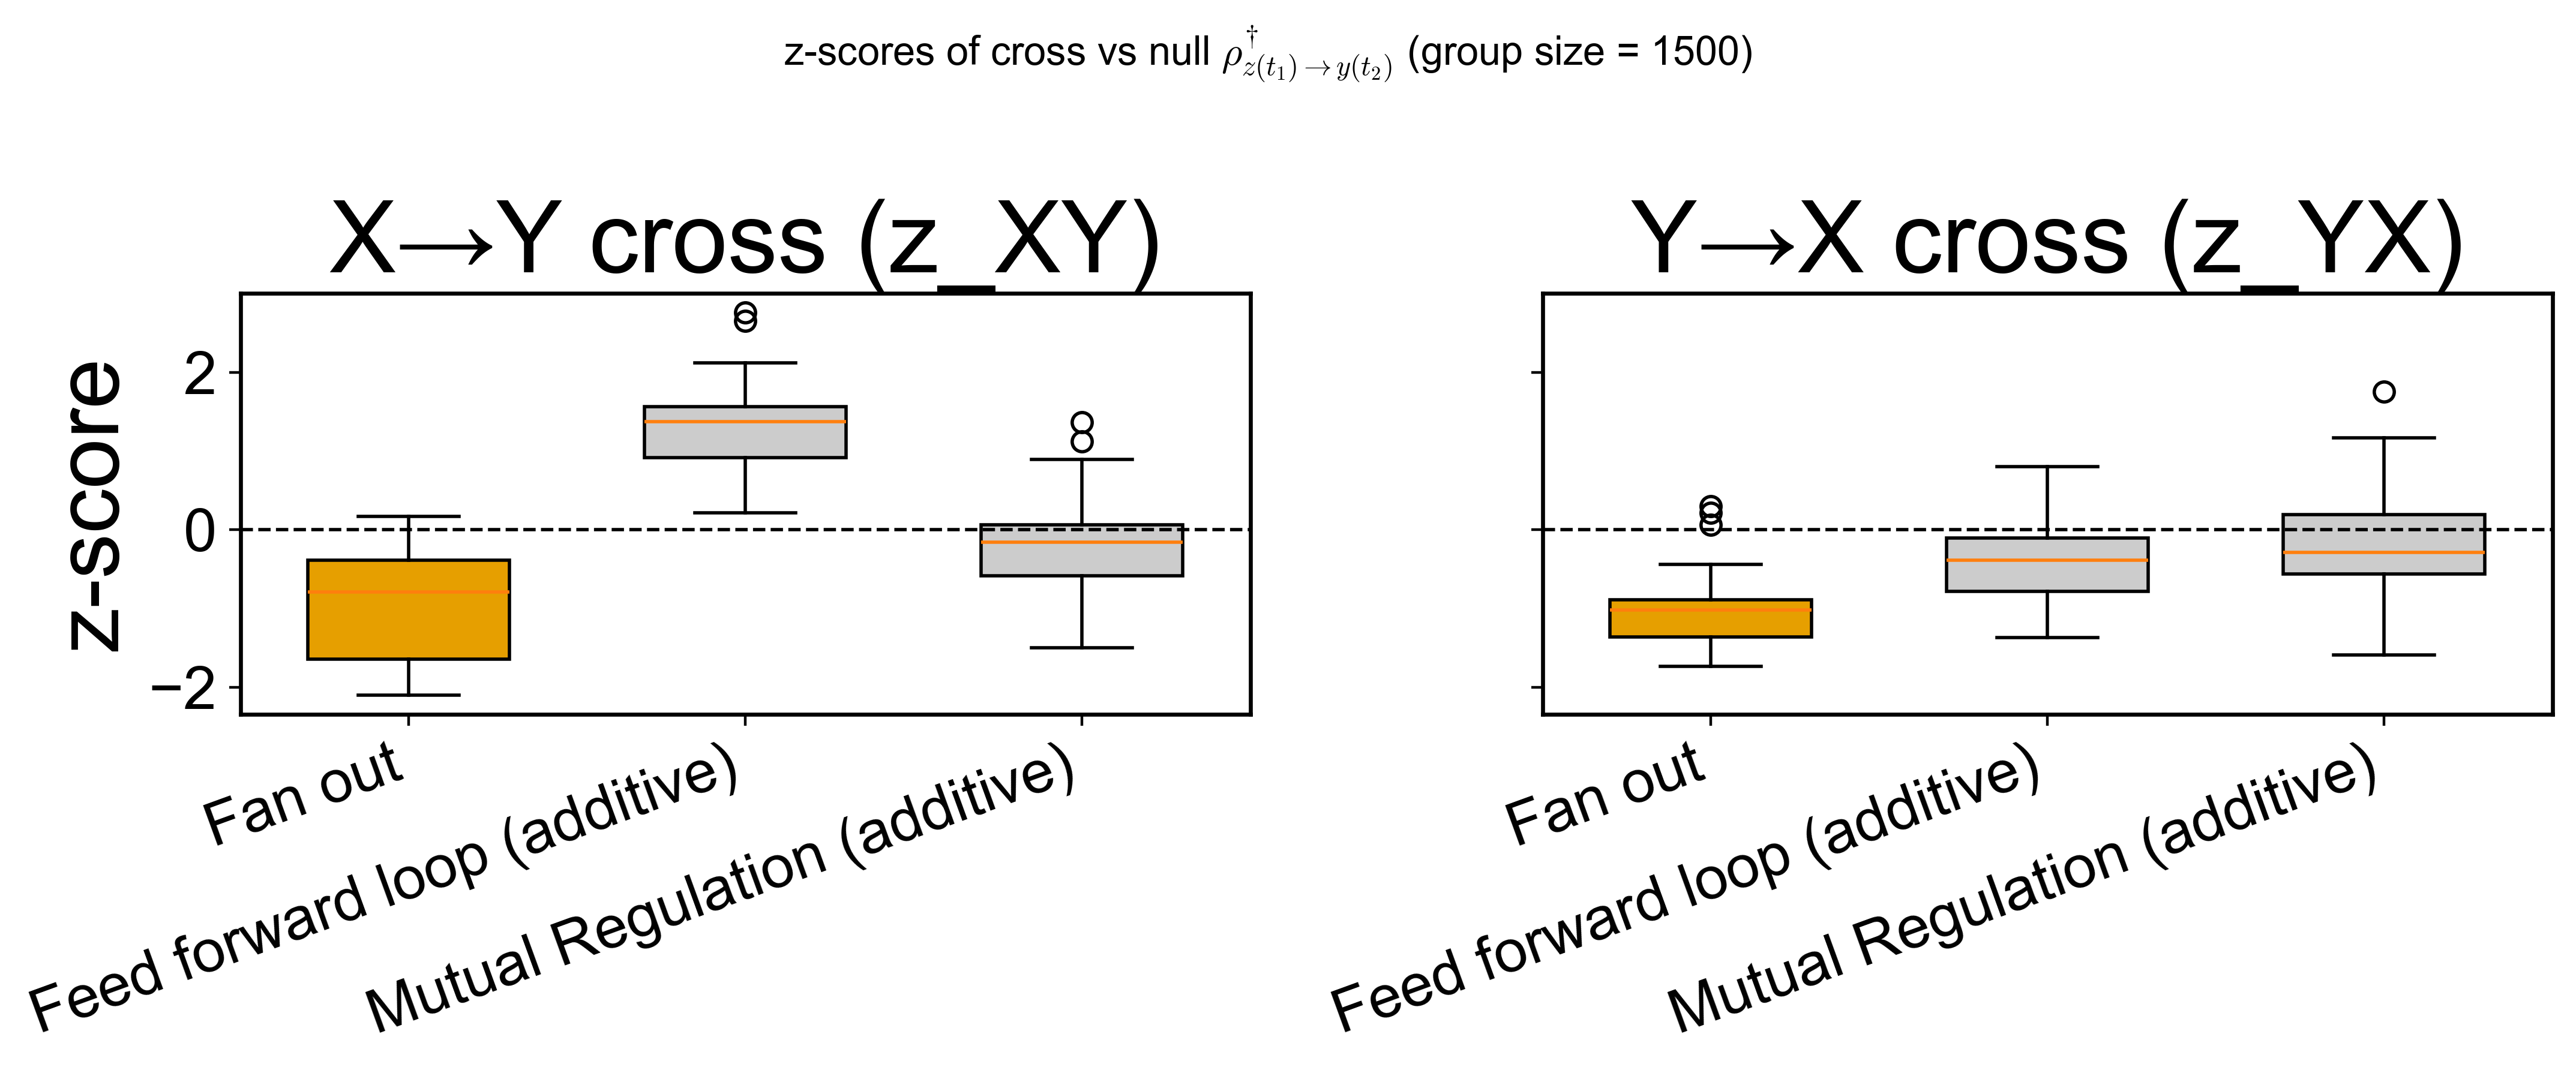


########################################
Processing interaction TYPE: and
########################################

------------------------------
Motif: Fan out
------------------------------
Found 20 files
  [file] df_rows_0_0_0_03122025_231037_ncells_6000_Fan_out_New_Median_2_3_621cea7d.csv
    rho_XY_cross=0.107, rho_YX_cross=0.089, mu_null=0.126, sd_null=0.026, z_XY=-0.730, z_YX=-1.449
  [file] df_rows_0_0_0_03122025_230406_ncells_6000_Fan_out_New_Median_2_7_41aa7a85.csv
    rho_XY_cross=0.107, rho_YX_cross=0.077, mu_null=0.121, sd_null=0.026, z_XY=-0.548, z_YX=-1.727
  [file] df_rows_0_0_0_03122025_222342_ncells_6000_Fan_out_New_Median_k_on0_3_1_6a23b0f0.csv
    rho_XY_cross=0.086, rho_YX_cross=0.083, mu_null=0.114, sd_null=0.026, z_XY=-1.126, z_YX=-1.243
  [file] df_rows_0_0_0_04122025_001948_ncells_6000_Fan_out_New_Median_k_on0_3_6_e20e08a1.csv
    rho_XY_cross=0.100, rho_YX_cross=0.114, mu_null=0.109, sd_null=0.025, z_XY=-0.346, z_YX=0.200
  [file] df_rows_0_0_0_03122025_2309

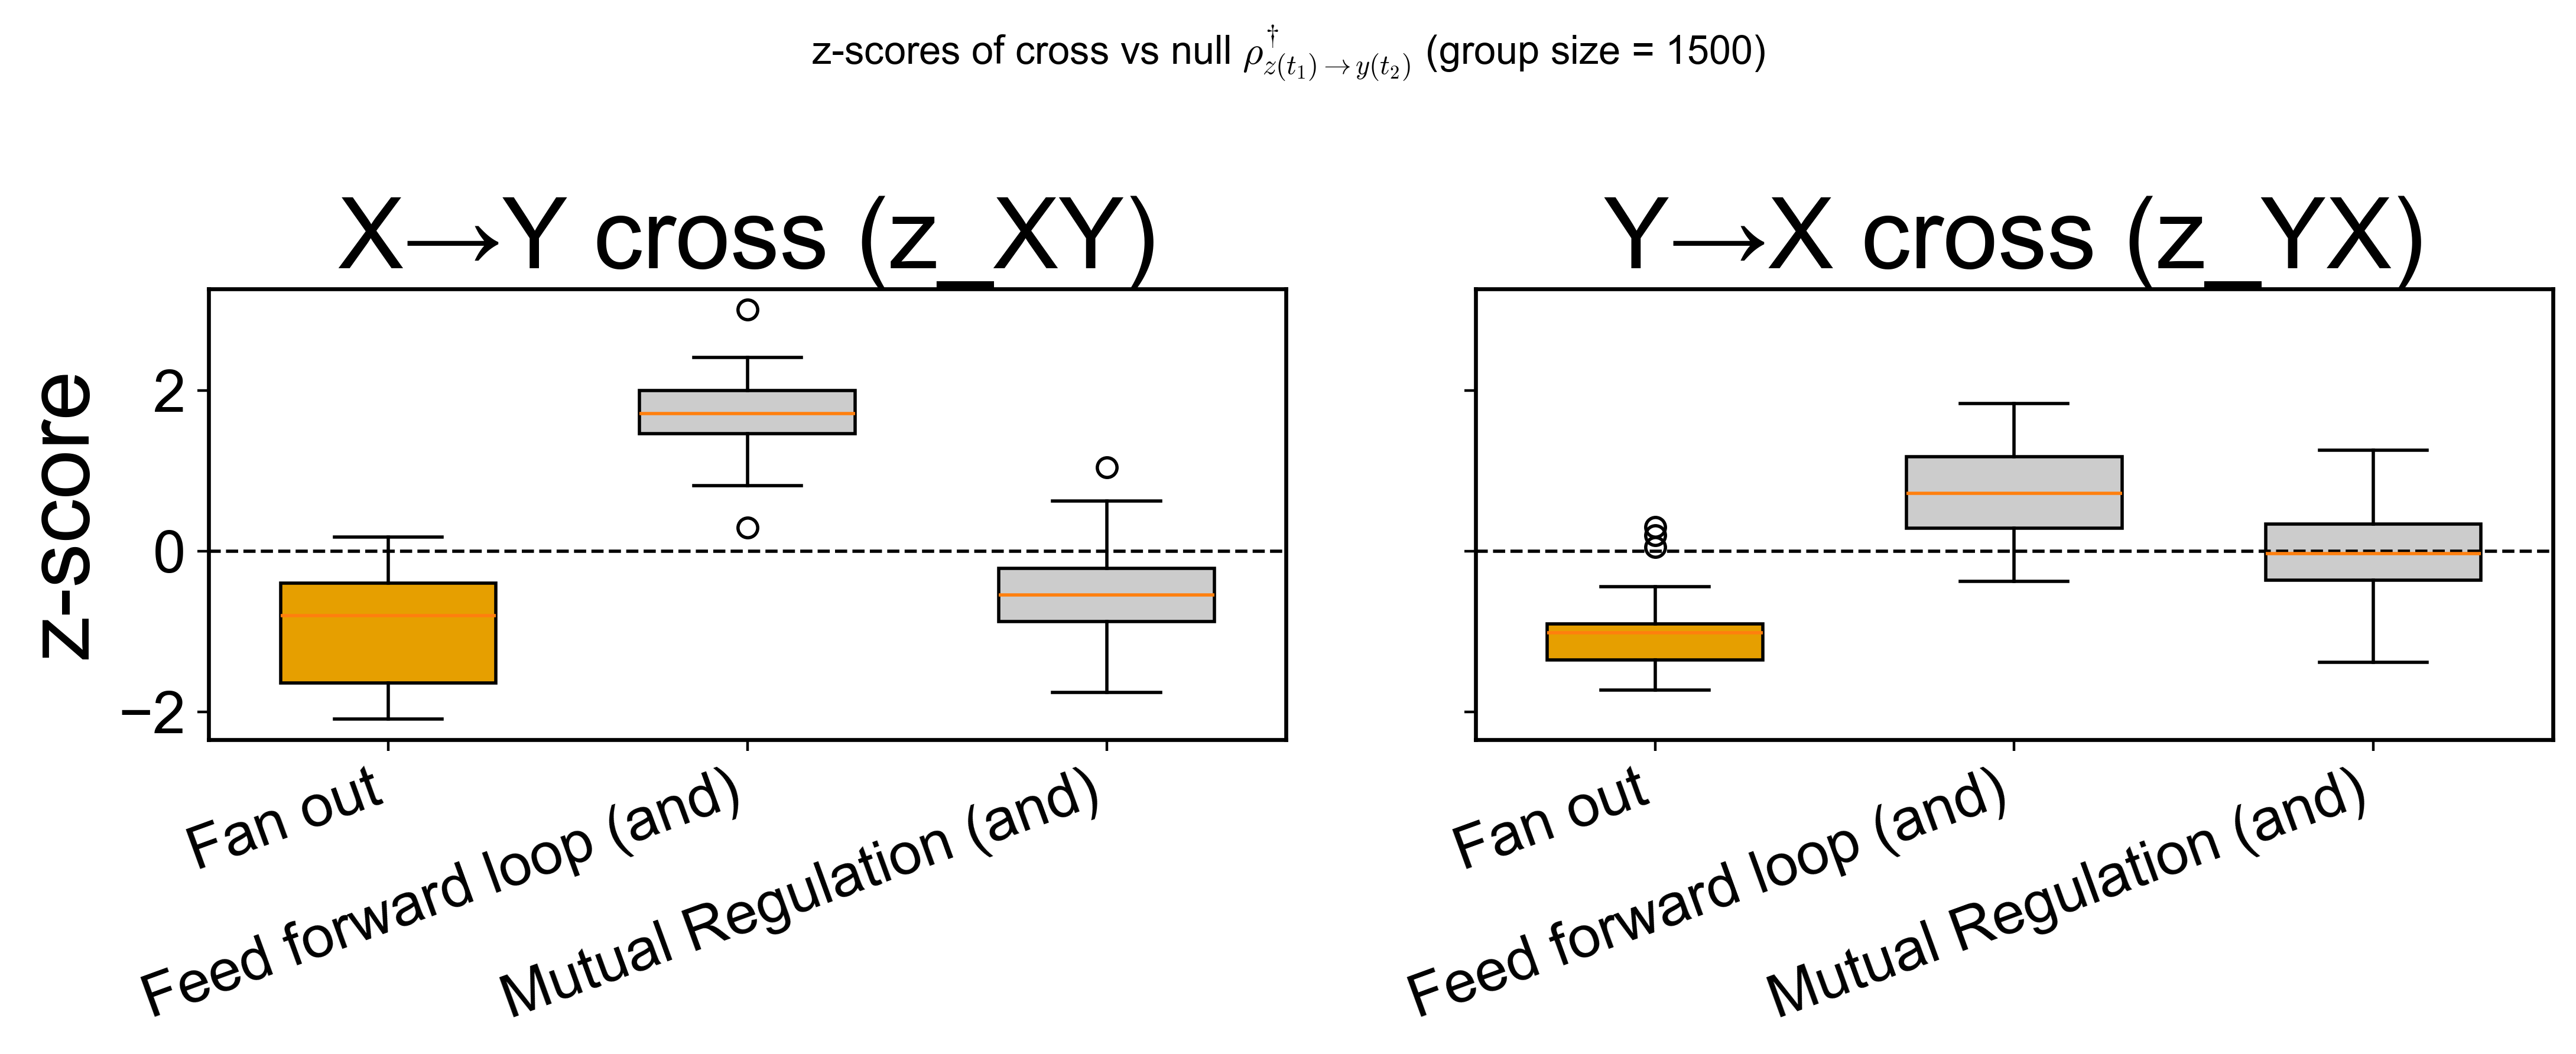


########################################
Processing interaction TYPE: or
########################################

------------------------------
Motif: Fan out
------------------------------
Found 20 files
  [file] df_rows_0_0_0_03122025_231037_ncells_6000_Fan_out_New_Median_2_3_621cea7d.csv
    rho_XY_cross=0.107, rho_YX_cross=0.089, mu_null=0.126, sd_null=0.025, z_XY=-0.750, z_YX=-1.471
  [file] df_rows_0_0_0_03122025_230406_ncells_6000_Fan_out_New_Median_2_7_41aa7a85.csv
    rho_XY_cross=0.107, rho_YX_cross=0.077, mu_null=0.121, sd_null=0.025, z_XY=-0.530, z_YX=-1.712
  [file] df_rows_0_0_0_03122025_222342_ncells_6000_Fan_out_New_Median_k_on0_3_1_6a23b0f0.csv
    rho_XY_cross=0.086, rho_YX_cross=0.083, mu_null=0.115, sd_null=0.025, z_XY=-1.145, z_YX=-1.263
  [file] df_rows_0_0_0_04122025_001948_ncells_6000_Fan_out_New_Median_k_on0_3_6_e20e08a1.csv
    rho_XY_cross=0.100, rho_YX_cross=0.114, mu_null=0.109, sd_null=0.026, z_XY=-0.352, z_YX=0.192
  [file] df_rows_0_0_0_03122025_23095

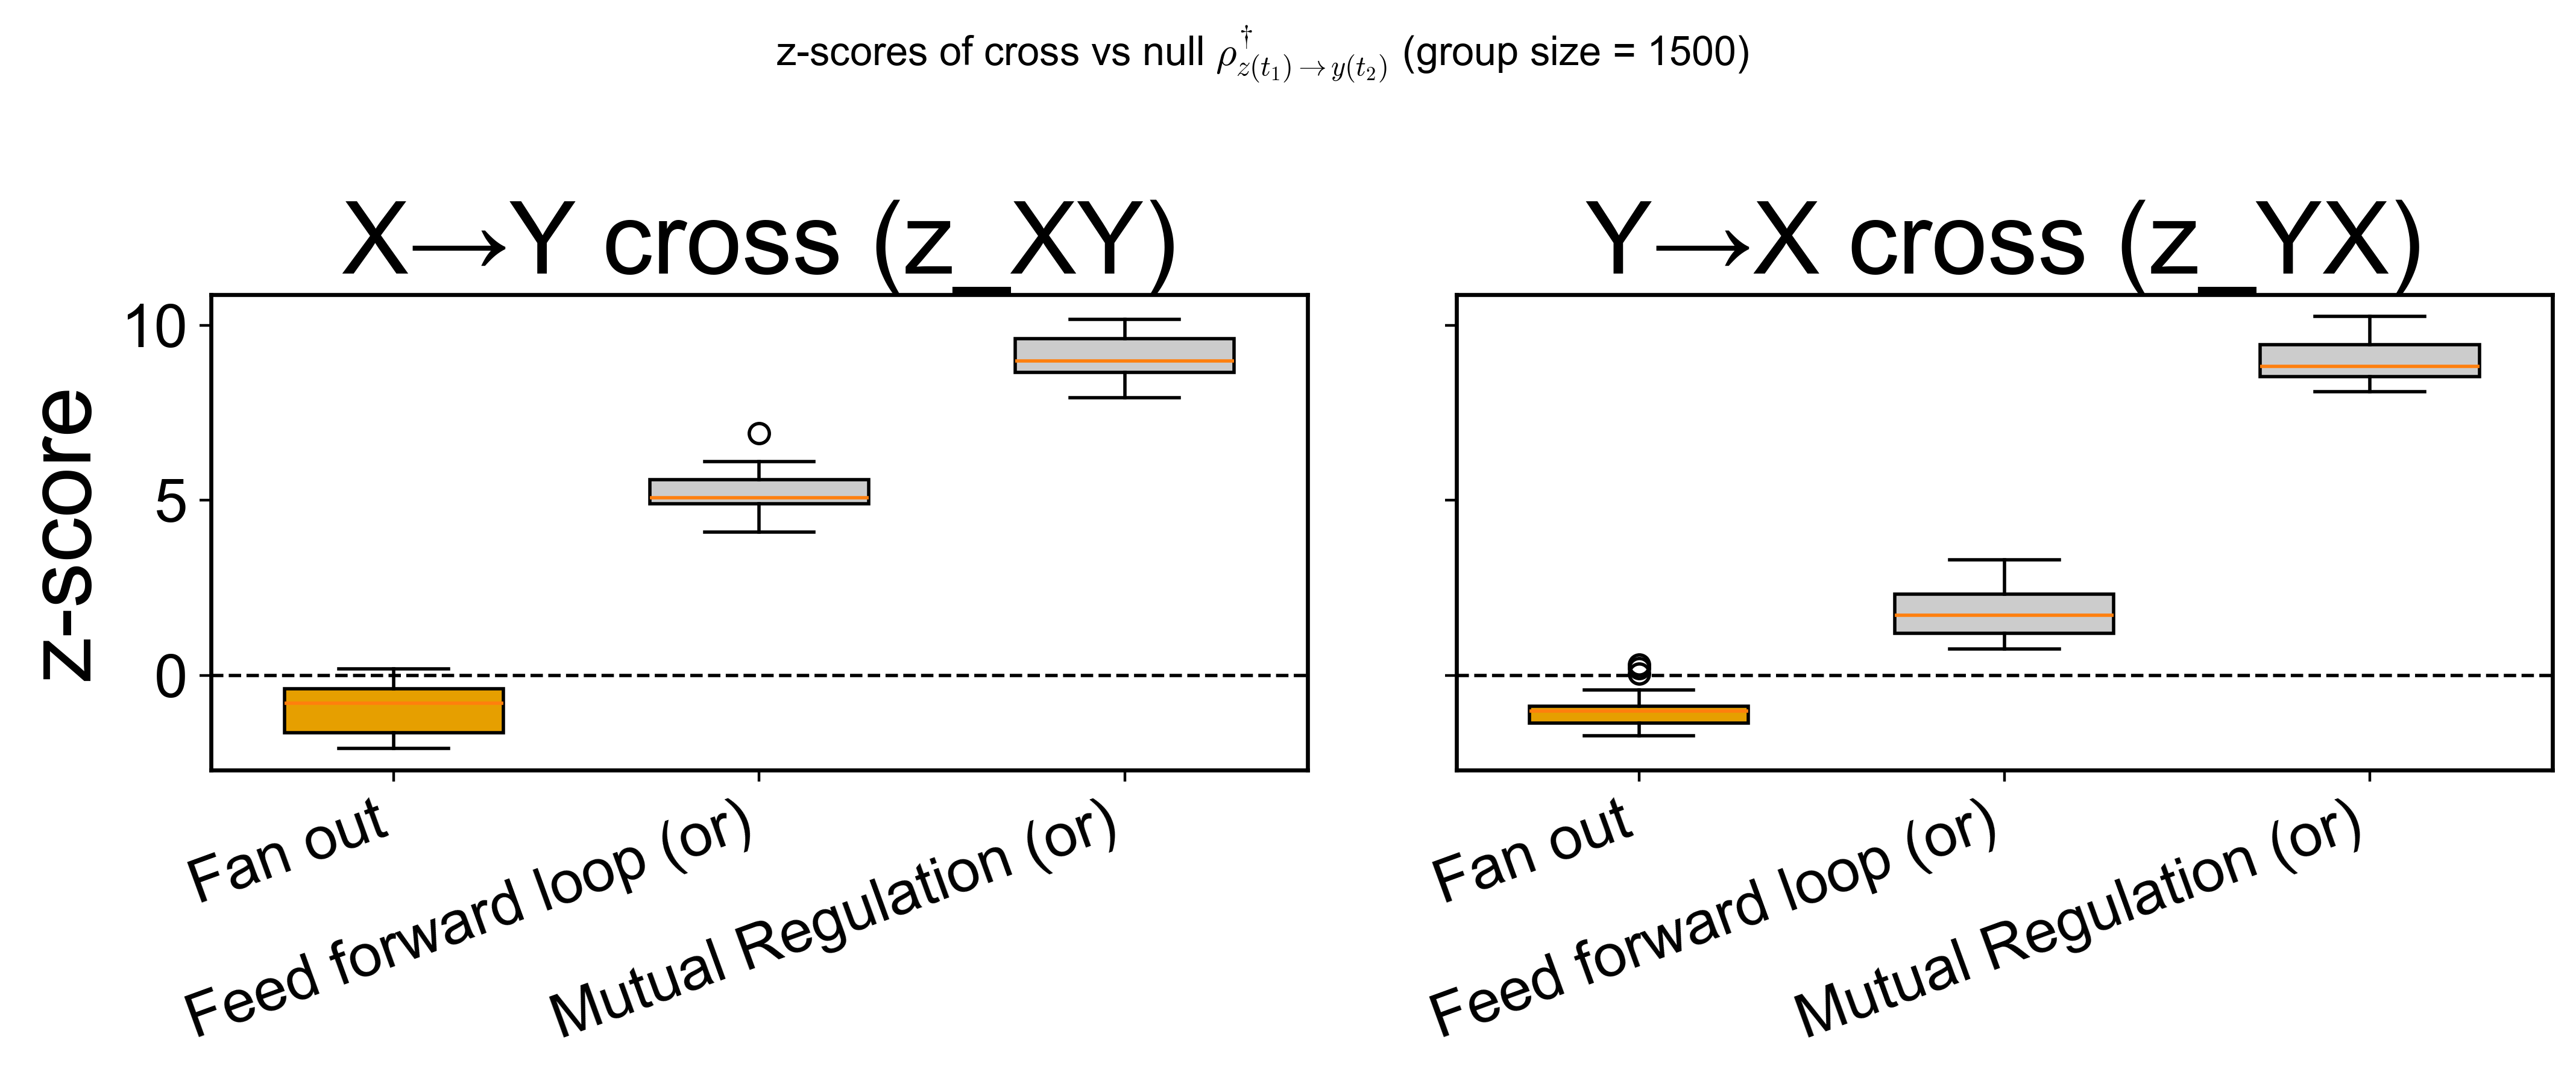

In [15]:
# ------------------------------------------------------------
# FILL THESE: all files per motif (put your ~20 paths each here)
# ------------------------------------------------------------
path_to_figure = "/home/gzu5140/Keerthana_b1042/grnInference/plots/warmflesh_simulations/"

# Colors for motifs (Okabe–Ito-ish)
MOTIF_COLORS = {
    "Fan out": "#E69F00",          # orange
    "Feed forward": "#56B4E9",# sky blue
    "Regulated Mutual": "#009E73", # bluish green
}

# ============================================================
# Main
# ============================================================
rng = np.random.default_rng(RNG_SEED)
for interaction_type, interaction_type_dict in motif_patterns.items():
    print("\n########################################")
    print(f"Processing interaction TYPE: {interaction_type}")
    print("########################################")
    # One z-score dict PER interaction type (group of 3 motifs)
    z_by_motif_XY = {motif_name: [] for motif_name in interaction_type_dict.keys()}
    z_by_motif_YX = {motif_name: [] for motif_name in interaction_type_dict.keys()}
    # Now loop over the motifs inside this interaction type
    for motif_name, info in interaction_type_dict.items():
        print("\n------------------------------")
        print(f"Motif: {motif_name}")
        print("------------------------------")
        folder  = info["folder"]
        pattern = info["pattern"]
        # find all matching csv files
        all_files = glob.glob(os.path.join(folder, "df*.csv"))
        file_list = [f for f in all_files if pattern in os.path.basename(f)]
        if len(file_list) > 20:
            file_list = file_list[:20]
        print(f"Found {len(file_list)} files")
        for path in file_list:
            if not os.path.isfile(path):
                print(f"  [skip] not found: {path}")
                continue
            z_XY, z_YX = compute_z_for_file(path, rng)
            if np.isfinite(z_XY):
                z_by_motif_XY[motif_name].append(z_XY)
            if np.isfinite(z_YX):
                z_by_motif_YX[motif_name].append(z_YX)
        print(f"  collected {len(z_by_motif_XY[motif_name])} z_XY and "
            f"{len(z_by_motif_YX[motif_name])} z_YX values.")
    # drop motifs with no data
    z_by_motif_XY = {m: v for m, v in z_by_motif_XY.items() if len(v) > 0}
    z_by_motif_YX = {m: v for m, v in z_by_motif_YX.items() if len(v) > 0}
    if not z_by_motif_XY:
        raise SystemExit("No z-scores collected; check file paths and settings.")
    plot_boxplots(z_by_motif_XY, z_by_motif_YX)
